In [1]:
from __future__ import annotations
from Regridding_functions import *
# load useful packages
import xarray as xr
import xesmf as xe
import numpy as np
xr.set_options(display_style='html')
import cftime
import matplotlib.pyplot as plt
from reading_routines_noresm import read_noresm_cmor, Modelinfo
import os

/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
from Long_CMIP6_functions import*

In [3]:
experiments = ['piControl', 'abrupt-4xCO2']

### **NorESM2-LM**

### **Total OHT**

In [4]:
path_1 = '/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM'
path_2 = 'r1i1p1f1/Omon/hfbasin/grz/latest'

start_y = 0
end_y = 500*12

hfbasins_gl_exp_noresm2, _, _, oc_lat_noresm2 = ocean_ht('NorESM2-LM', path_1, path_2, experiments, start_y, end_y, 'hfbasin')

Original: 'atlantic_arctic_ocean', Cleaned: 'atlantic_arctic_ocean', Mapped: 'atlantic_arctic_ocean'
Original: 'atlantic_arctic_extended_ocean', Cleaned: 'atlantic_arctic_extended_ocean', Mapped: 'unknown_atlantic_arctic_extended_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Original: 'global_ocean', Cleaned: 'global_ocean', Mapped: 'global_ocean'
Basin Mapping: {0: 'atlantic_arctic_ocean', 1: 'unknown_atlantic_arctic_extended_ocean', 2: 'indian_pacific_ocean', 3: 'global_ocean'}
Original: 'atlantic_arctic_ocean', Cleaned: 'atlantic_arctic_ocean', Mapped: 'atlantic_arctic_ocean'
Original: 'atlantic_arctic_extended_ocean', Cleaned: 'atlantic_arctic_extended_ocean', Mapped: 'unknown_atlantic_arctic_extended_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Original: 'global_ocean', Cleaned: 'global_ocean', Mapped: 'global_ocean'
Basin Mapping: {0: 'atlantic_arctic_ocean', 1: 

In [5]:
oc_lat_noresm2

array([-80., -79., -78., -77., -76., -75., -74., -73., -72., -71., -70.,
       -69., -68., -67., -66., -65., -64., -63., -62., -61., -60., -59.,
       -58., -57., -56., -55., -54., -53., -52., -51., -50., -49., -48.,
       -47., -46., -45., -44., -43., -42., -41., -40., -39., -38., -37.,
       -36., -35., -34., -33., -32., -31., -30., -29., -28., -27., -26.,
       -25., -24., -23., -22., -21., -20., -19., -18., -17., -16., -15.,
       -14., -13., -12., -11., -10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,
        -3.,  -2.,  -1.,   0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,
         8.,   9.,  10.,  11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,
        19.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,
        30.,  31.,  32.,  33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,
        41.,  42.,  43.,  44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,
        52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,
        63.,  64.,  65.,  66.,  67.,  68.,  69.,  7

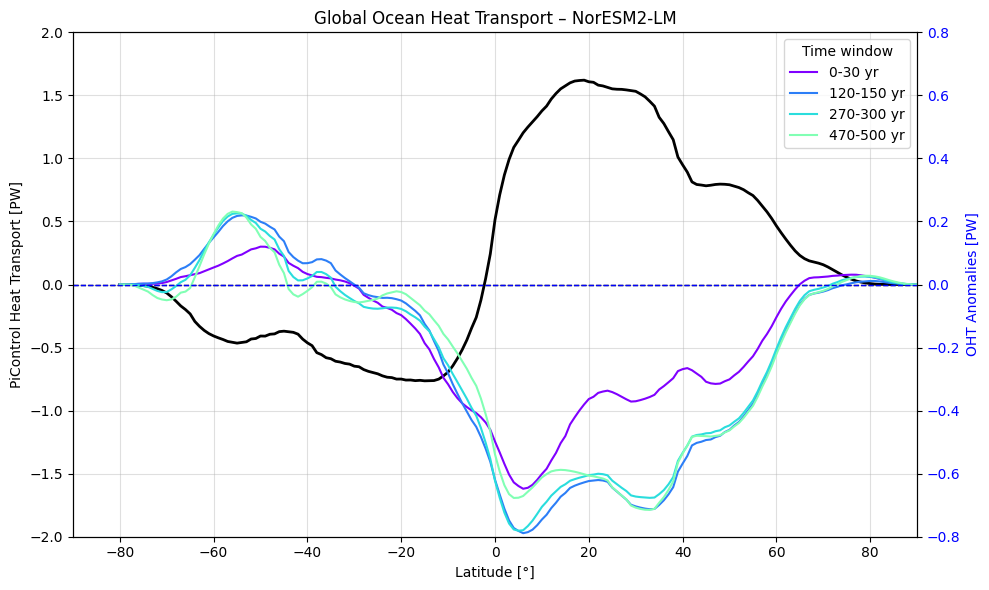

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_noresm2, np.mean(hfbasins_gl_exp_noresm2[0, :, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:4], colors):
    anom = (np.mean(hfbasins_gl_exp_noresm2[1, start:end, :], axis=0)\
          - np.mean(hfbasins_gl_exp_noresm2[0, 0:30, :], axis=0))
    ax2.plot(oc_lat_noresm2, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Global Ocean Heat Transport – NorESM2-LM')
plt.tight_layout()
plt.show()

### **OHT due to Eddy advection**

In [7]:
path_1 = '/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM'
path_2 = 'r1i1p1f1/Omon/hfbasinpmadv/grz/latest'

start_y = 0
end_y = 500*12

hfbasinpmadv_gl_exp_noresm2, _, _, oc_lat_adv_noresm2 = ocean_ht('NorESM2-LM', path_1, path_2, experiments, start_y, end_y, 'hfbasinpmadv')

Original: 'atlantic_arctic_ocean', Cleaned: 'atlantic_arctic_ocean', Mapped: 'atlantic_arctic_ocean'
Original: 'atlantic_arctic_extended_ocean', Cleaned: 'atlantic_arctic_extended_ocean', Mapped: 'unknown_atlantic_arctic_extended_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Original: 'global_ocean', Cleaned: 'global_ocean', Mapped: 'global_ocean'
Basin Mapping: {0: 'atlantic_arctic_ocean', 1: 'unknown_atlantic_arctic_extended_ocean', 2: 'indian_pacific_ocean', 3: 'global_ocean'}
Original: 'atlantic_arctic_ocean', Cleaned: 'atlantic_arctic_ocean', Mapped: 'atlantic_arctic_ocean'
Original: 'atlantic_arctic_extended_ocean', Cleaned: 'atlantic_arctic_extended_ocean', Mapped: 'unknown_atlantic_arctic_extended_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Original: 'global_ocean', Cleaned: 'global_ocean', Mapped: 'global_ocean'
Basin Mapping: {0: 'atlantic_arctic_ocean', 1: 

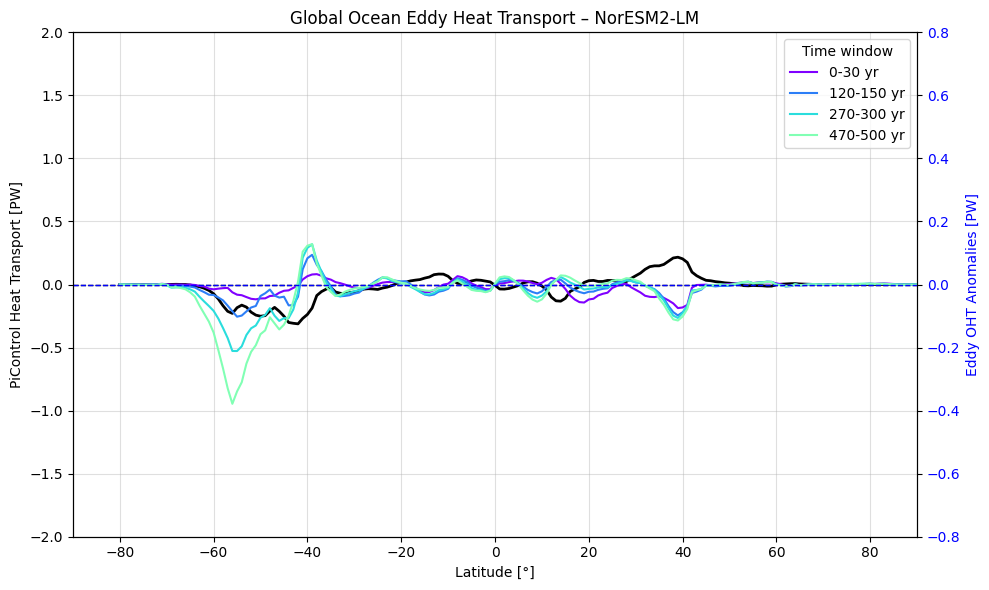

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_adv_noresm2, np.mean(hfbasinpmadv_gl_exp_noresm2[0, :, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:4], colors):
    anom = (np.mean(hfbasinpmadv_gl_exp_noresm2[1, start:end, :], axis=0)\
          - np.mean(hfbasinpmadv_gl_exp_noresm2[0, 0:30, :], axis=0))
    ax2.plot(oc_lat_noresm2, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('Eddy OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Global Ocean Eddy Heat Transport – NorESM2-LM')
plt.tight_layout()
plt.show()

### **Mean Flow**

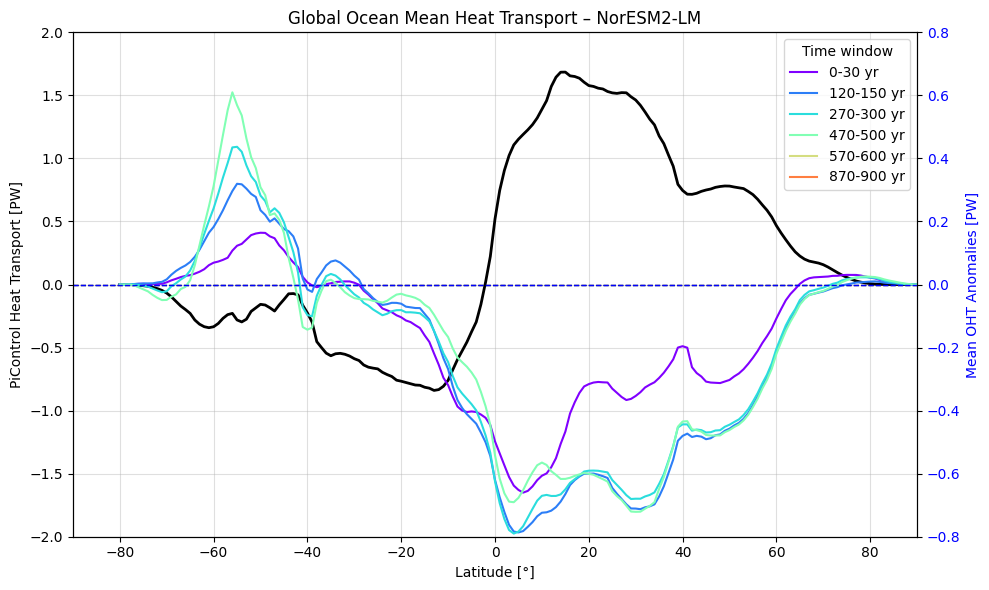

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 6))

mean_all_pi = np.mean(hfbasins_gl_exp_noresm2[0, :, :], axis = 0)
mean_adv_pi = np.mean(hfbasinpmadv_gl_exp_noresm2[0, :, :], axis = 0)

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_adv_noresm2, mean_all_pi - mean_adv_pi, color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:6], colors):
    anom_all = (np.mean(hfbasins_gl_exp_noresm2[1, start:end, :], axis=0)\
          - np.mean(hfbasins_gl_exp_noresm2[0, 0:30, :], axis=0))

    anom_adv = (np.mean(hfbasinpmadv_gl_exp_noresm2[1, start:end, :], axis=0)\
          - np.mean(hfbasinpmadv_gl_exp_noresm2[0, 0:30, :], axis=0))
    ax2.plot(oc_lat_noresm2, anom_all - anom_adv, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('Mean OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Global Ocean Mean Heat Transport – NorESM2-LM')
plt.tight_layout()
plt.show()

### **Timeseries**

In [28]:
# Total 

idx_N = np.where(oc_lat_noresm2==40)

oht_tot_pi_40N_noresm2 = hfbasins_gl_exp_noresm2[0, :, idx_N].squeeze()
oht_tot_x4_40N_noresm2 = hfbasins_gl_exp_noresm2[1, :, idx_N].squeeze()

roll_oht_tot_pi_40N_noresm2 = rolling_average_ts(oht_tot_pi_40N_noresm2, 11)
roll_oht_tot_x4_40N_noresm2 = rolling_average_ts(oht_tot_x4_40N_noresm2, 11)

idx_S = np.where(oc_lat_noresm2==-40)

oht_tot_pi_40S_noresm2 = hfbasins_gl_exp_noresm2[0, :, idx_S].squeeze()
oht_tot_x4_40S_noresm2 = hfbasins_gl_exp_noresm2[1, :, idx_S].squeeze()

roll_oht_tot_pi_40S_noresm2 = rolling_average_ts(oht_tot_pi_40S_noresm2, 11)
roll_oht_tot_x4_40S_noresm2 = rolling_average_ts(oht_tot_x4_40S_noresm2, 11)
# Eddy

oht_eddy_pi_40N_noresm2 = hfbasinpmadv_gl_exp_noresm2[0, :, idx_N].squeeze()
oht_eddy_x4_40N_noresm2 = hfbasinpmadv_gl_exp_noresm2[1, :, idx_N].squeeze()

oht_eddy_pi_40S_noresm2 = hfbasinpmadv_gl_exp_noresm2[0, :, idx_S].squeeze()
oht_eddy_x4_40S_noresm2 = hfbasinpmadv_gl_exp_noresm2[1, :, idx_S].squeeze()

roll_oht_eddy_pi_40N_noresm2 = rolling_average_ts(oht_eddy_pi_40N_noresm2, 11)
roll_oht_eddy_x4_40N_noresm2 = rolling_average_ts(oht_eddy_x4_40N_noresm2, 11)
roll_oht_eddy_pi_40S_noresm2 = rolling_average_ts(oht_eddy_pi_40S_noresm2, 11)
roll_oht_eddy_x4_40S_noresm2 = rolling_average_ts(oht_eddy_x4_40S_noresm2, 11)

# Mean 

oht_mean_pi_40N_noresm2 = oht_tot_pi_40N_noresm2 - oht_eddy_pi_40N_noresm2
oht_mean_x4_40N_noresm2 = oht_tot_x4_40N_noresm2 - oht_eddy_x4_40N_noresm2

oht_mean_pi_40S_noresm2 = oht_tot_pi_40S_noresm2 - oht_eddy_pi_40S_noresm2
oht_mean_x4_40S_noresm2 = oht_tot_x4_40S_noresm2 - oht_eddy_x4_40S_noresm2


roll_oht_mean_pi_40N_noresm2 = rolling_average_ts(oht_mean_pi_40N_noresm2, 11)
roll_oht_mean_x4_40N_noresm2 = rolling_average_ts(oht_mean_x4_40N_noresm2, 11)
roll_oht_mean_pi_40S_noresm2 = rolling_average_ts(oht_mean_pi_40S_noresm2, 11)
roll_oht_mean_x4_40S_noresm2 = rolling_average_ts(oht_mean_x4_40S_noresm2, 11)

### **IPSL-CM6A-LR (v20200326)**

In [13]:
path_1 = '/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR'
path_2 = 'r1i1p1f1/Omon/hfbasin/gn/v20200326'

start_y = 0
end_y = 900*12

hfbasins_gl_exp_ipsl, _, _, oc_lat_ipsl = ocean_ht('IPSL-CM6A-LR', path_1, path_2, experiments, start_y, end_y, 'hfbasin')

Original: 'Global', Cleaned: 'Global', Mapped: 'global_ocean'
Original: 'Atlantic', Cleaned: 'Atlantic', Mapped: 'atlantic_arctic_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Basin Mapping: {0: 'global_ocean', 1: 'atlantic_arctic_ocean', 2: 'indian_pacific_ocean'}
Original: 'Global', Cleaned: 'Global', Mapped: 'global_ocean'
Original: 'Atlantic', Cleaned: 'Atlantic', Mapped: 'atlantic_arctic_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Basin Mapping: {0: 'global_ocean', 1: 'atlantic_arctic_ocean', 2: 'indian_pacific_ocean'}


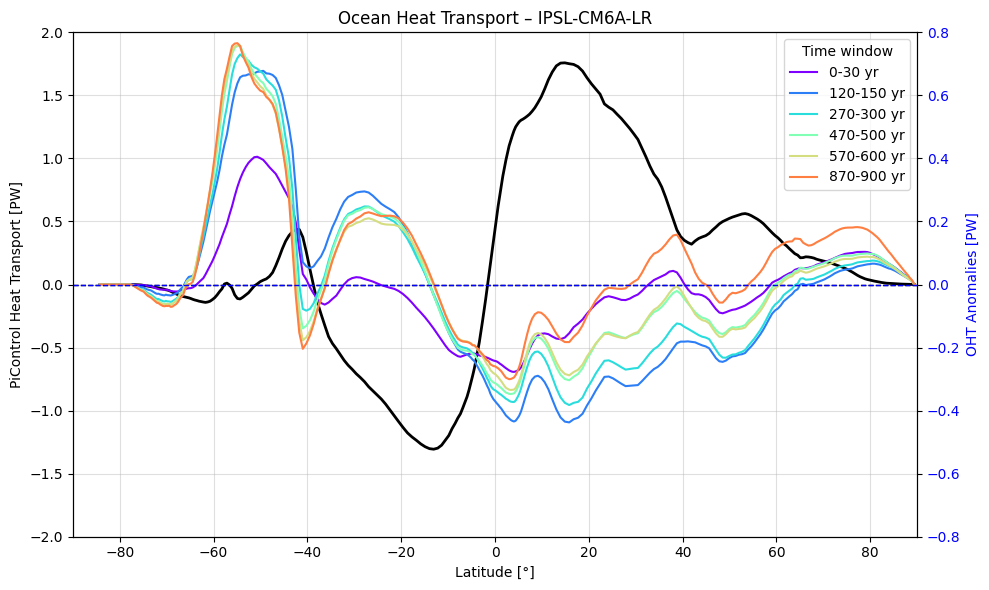

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_ipsl, np.mean(hfbasins_gl_exp_ipsl[0, :, :, 0], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:-1], colors):
    anom = (np.mean(hfbasins_gl_exp_ipsl[1, start:end, :, 0], axis=0)\
          - np.mean(hfbasins_gl_exp_ipsl[0, 0:30, :, 0], axis=0))
    ax2.plot(oc_lat_ipsl, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)

ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Ocean Heat Transport – IPSL-CM6A-LR')
plt.tight_layout()
plt.show()

### **Eddy flow**

In [15]:
path_1 = '/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR'
path_2 = 'r1i1p1f1/Omon/hfbasinpmadv/gn/v20200326'

start_y = 0
end_y = 900*12

hfbasinpmadv_gl_exp_ipsl, _, _, oc_lat_adv_ipsl = ocean_ht('IPSL-CM6A-LR', path_1, path_2, experiments, start_y, end_y, 'hfbasinpmadv')

Original: 'Global', Cleaned: 'Global', Mapped: 'global_ocean'
Original: 'Atlantic', Cleaned: 'Atlantic', Mapped: 'atlantic_arctic_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Basin Mapping: {0: 'global_ocean', 1: 'atlantic_arctic_ocean', 2: 'indian_pacific_ocean'}
Original: 'Global', Cleaned: 'Global', Mapped: 'global_ocean'
Original: 'Atlantic', Cleaned: 'Atlantic', Mapped: 'atlantic_arctic_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Basin Mapping: {0: 'global_ocean', 1: 'atlantic_arctic_ocean', 2: 'indian_pacific_ocean'}


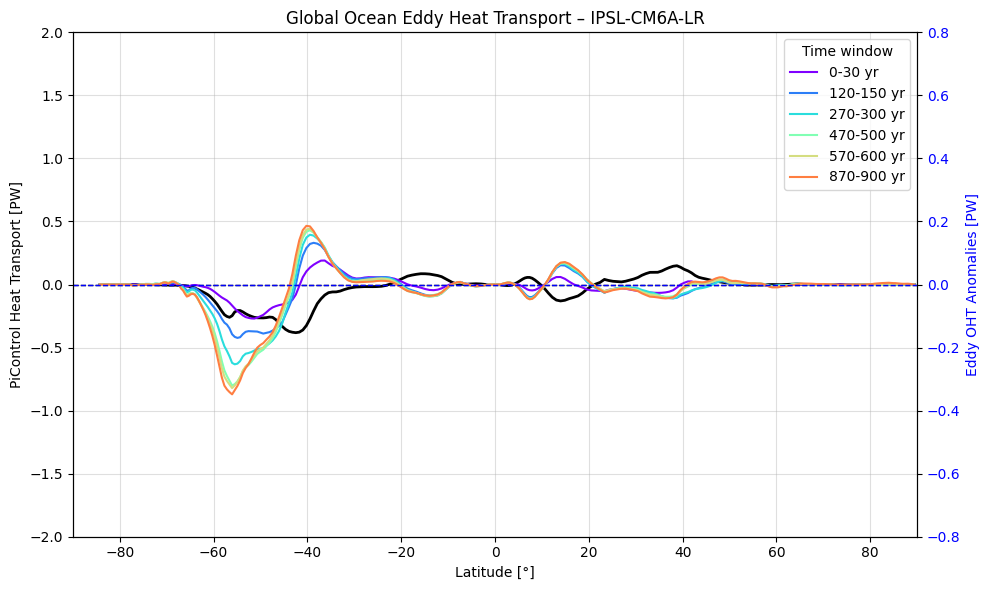

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_adv_ipsl, np.mean(hfbasinpmadv_gl_exp_ipsl[0, :, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:6], colors):
    anom = (np.mean(hfbasinpmadv_gl_exp_ipsl[1, start:end, :], axis=0)\
          - np.mean(hfbasinpmadv_gl_exp_ipsl[0, 0:30, :], axis=0))
    ax2.plot(oc_lat_adv_ipsl, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('Eddy OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Global Ocean Eddy Heat Transport – IPSL-CM6A-LR')
plt.tight_layout()
plt.show()

### **Mean Flow**

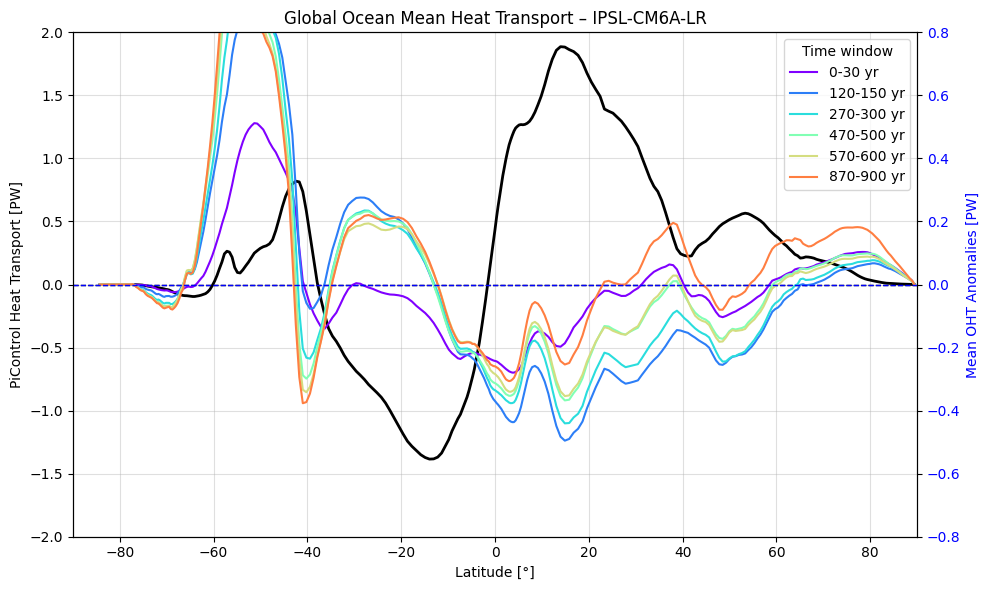

In [23]:
fig, ax1 = plt.subplots(figsize=(10, 6))
mean_ipsl = np.mean(hfbasins_gl_exp_ipsl[0, :, :], axis = 0) -np.mean(hfbasinpmadv_gl_exp_ipsl[0, :, :], axis = 0)

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_adv_ipsl, mean_ipsl, color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:6], colors):
    anom_all = (np.mean(hfbasins_gl_exp_ipsl[1, start:end, :], axis=0)\
          - np.mean(hfbasins_gl_exp_ipsl[0, 0:30, :], axis=0))

    anom_adv = (np.mean(hfbasinpmadv_gl_exp_ipsl[1, start:end, :], axis=0)\
          - np.mean(hfbasinpmadv_gl_exp_ipsl[0, 0:30, :], axis=0))
    ax2.plot(oc_lat_adv_ipsl, anom_all-anom_adv, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('Mean OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Global Ocean Mean Heat Transport – IPSL-CM6A-LR')
plt.tight_layout()
plt.show()

### **Timeseries**

In [24]:
def rolling_average_ts(data, window_size):

    time = (data.shape)[0]
    output_length = time - window_size + 1
    result = np.zeros(output_length)

    for i in range(output_length):
        window = data[i:i+window_size]  # shape: (#models, window_size, #latitudes)
        result[i] = np.sum(window, axis=0) / window_size

    return result

In [27]:
# Total 

idx_N = np.abs(oc_lat_ipsl - 40).argmin()

oht_tot_pi_40N_ipsl = hfbasins_gl_exp_ipsl[0, :, idx_N].squeeze()
oht_tot_x4_40N_ipsl = hfbasins_gl_exp_ipsl[1, :, idx_N].squeeze()

roll_oht_tot_pi_40N_ipsl = rolling_average_ts(oht_tot_pi_40N_ipsl, 11)
roll_oht_tot_x4_40N_ipsl = rolling_average_ts(oht_tot_x4_40N_ipsl, 11)

idx_S = np.abs(oc_lat_ipsl + 40).argmin()

oht_tot_pi_40S_ipsl = hfbasins_gl_exp_ipsl[0, :, idx_S].squeeze()
oht_tot_x4_40S_ipsl = hfbasins_gl_exp_ipsl[1, :, idx_S].squeeze()

roll_oht_tot_pi_40S_ipsl = rolling_average_ts(oht_tot_pi_40S_ipsl, 11)
roll_oht_tot_x4_40S_ipsl = rolling_average_ts(oht_tot_x4_40S_ipsl, 11)
# Eddy

oht_eddy_pi_40N_ipsl = hfbasinpmadv_gl_exp_ipsl[0, :, idx_N].squeeze()
oht_eddy_x4_40N_ipsl = hfbasinpmadv_gl_exp_ipsl[1, :, idx_N].squeeze()

oht_eddy_pi_40S_ipsl = hfbasinpmadv_gl_exp_ipsl[0, :, idx_S].squeeze()
oht_eddy_x4_40S_ipsl = hfbasinpmadv_gl_exp_ipsl[1, :, idx_S].squeeze()

roll_oht_eddy_pi_40N_ipsl = rolling_average_ts(oht_eddy_pi_40N_ipsl, 11)
roll_oht_eddy_x4_40N_ipsl = rolling_average_ts(oht_eddy_x4_40N_ipsl, 11)
roll_oht_eddy_pi_40S_ipsl = rolling_average_ts(oht_eddy_pi_40S_ipsl, 11)
roll_oht_eddy_x4_40S_ipsl = rolling_average_ts(oht_eddy_x4_40S_ipsl, 11)

# Mean 

oht_mean_pi_40N_ipsl = oht_tot_pi_40N_ipsl - oht_eddy_pi_40N_ipsl
oht_mean_x4_40N_ipsl = oht_tot_x4_40N_ipsl - oht_eddy_x4_40N_ipsl

oht_mean_pi_40S_ipsl = oht_tot_pi_40S_ipsl - oht_eddy_pi_40S_ipsl
oht_mean_x4_40S_ipsl = oht_tot_x4_40S_ipsl - oht_eddy_x4_40S_ipsl


roll_oht_mean_pi_40N_ipsl = rolling_average_ts(oht_mean_pi_40N_ipsl, 11)
roll_oht_mean_x4_40N_ipsl = rolling_average_ts(oht_mean_x4_40N_ipsl, 11)
roll_oht_mean_pi_40S_ipsl = rolling_average_ts(oht_mean_pi_40S_ipsl, 11)
roll_oht_mean_x4_40S_ipsl = rolling_average_ts(oht_mean_x4_40S_ipsl, 11)

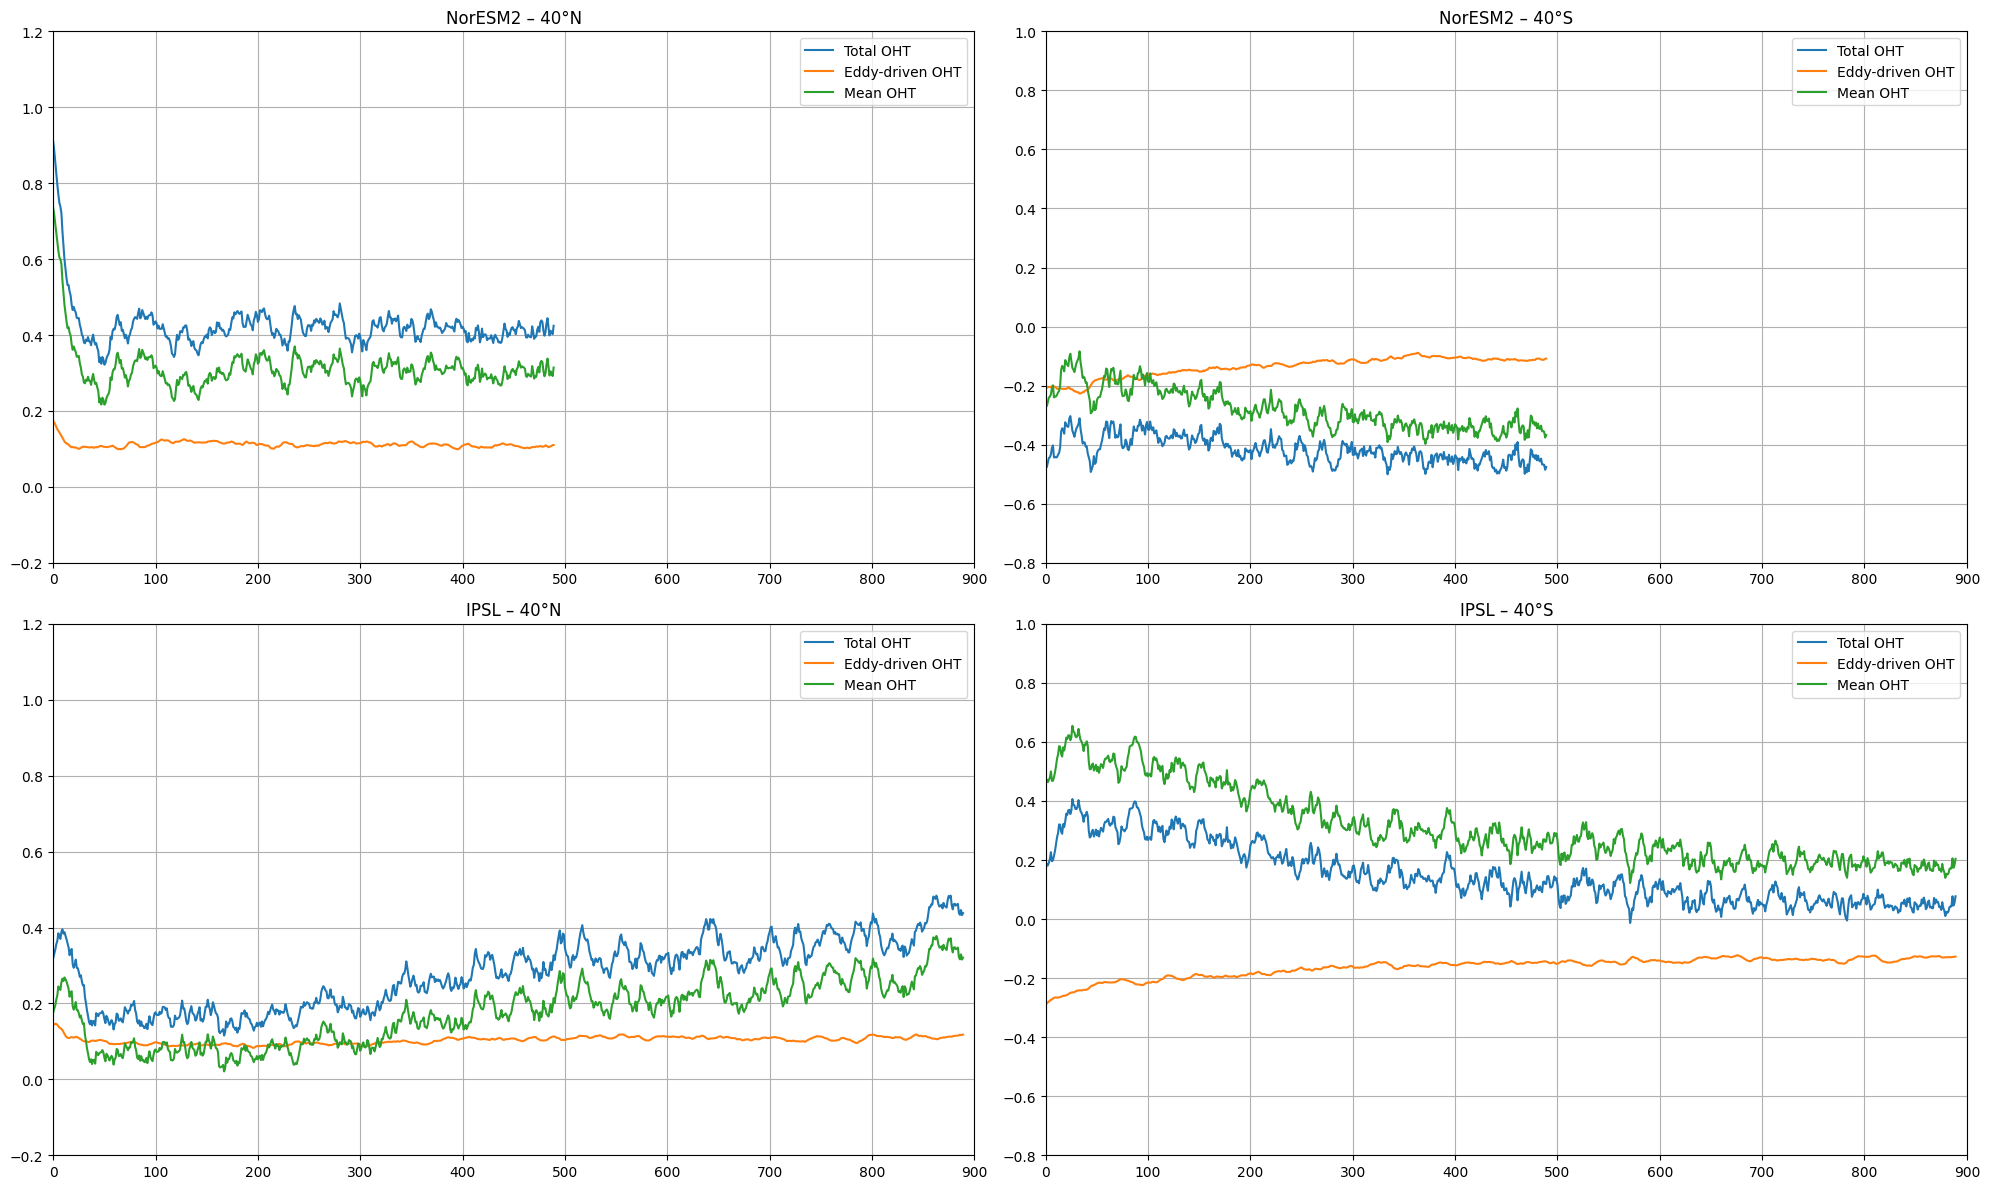

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
(ax1, ax2), (ax3, ax4) = axes

# -------------------------------
# 1) NORESM2 — Northern Hemisphere
# -------------------------------
ax1.plot(roll_oht_tot_x4_40N_noresm2, label='Total OHT')
ax1.plot(roll_oht_eddy_x4_40N_noresm2, label='Eddy-driven OHT')
ax1.plot(roll_oht_mean_x4_40N_noresm2, label='Mean OHT')

ax1.set_xlim(0, 900)
ax1.set_ylim(-0.2, 1.2)
ax1.set_title("NorESM2 – 40°N")
ax1.legend()
ax1.grid(True)


# -------------------------------
# 2) NORESM2 — Southern Hemisphere
# -------------------------------
ax2.plot(roll_oht_tot_x4_40S_noresm2, label='Total OHT')
ax2.plot(roll_oht_eddy_x4_40S_noresm2, label='Eddy-driven OHT')
ax2.plot(roll_oht_mean_x4_40S_noresm2, label='Mean OHT')

ax2.set_xlim(0, 900)
ax2.set_ylim(-0.8, 1.0)
ax2.set_title("NorESM2 – 40°S")
ax2.legend()
ax2.grid(True)


# -------------------------------
# 3) IPSL — Northern Hemisphere
# -------------------------------
ax3.plot(roll_oht_tot_x4_40N_ipsl, label='Total OHT')
ax3.plot(roll_oht_eddy_x4_40N_ipsl, label='Eddy-driven OHT')
ax3.plot(roll_oht_mean_x4_40N_ipsl, label='Mean OHT')

ax3.set_xlim(0, 900)
ax3.set_ylim(-0.2, 1.2)
ax3.set_title("IPSL – 40°N")
ax3.legend()
ax3.grid(True)


# -------------------------------
# 4) IPSL — Southern Hemisphere
# -------------------------------
ax4.plot(roll_oht_tot_x4_40S_ipsl, label='Total OHT')
ax4.plot(roll_oht_eddy_x4_40S_ipsl, label='Eddy-driven OHT')
ax4.plot(roll_oht_mean_x4_40S_ipsl, label='Mean OHT')

ax4.set_xlim(0, 900)
ax4.set_ylim(-0.8, 1.0)
ax4.set_title("IPSL – 40°S")
ax4.legend()
ax4.grid(True)


# -------------------------------
# Final layout tweaks
# -------------------------------
plt.tight_layout()
plt.show()